# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from pymongo.server_api import ServerApi
import os
from dotenv import load_dotenv
from pathlib import Path

In [2]:
load_dotenv("/zfs/projects/students/ltdarc-usf-intern-2025/LLM_benchmarks/.env")

username = os.getenv("MONGO_DB_USERNAME")
password = os.getenv("MONGO_DB_PASSWORD")

# Connect to MongoDB

In [3]:
hosts = [
    'darc-data-shard-00-00.9fjam.mongodb.net:27017',
    'darc-data-shard-00-01.9fjam.mongodb.net:27017',
    'darc-data-shard-00-02.9fjam.mongodb.net:27017'
]
setName = 'DARC-Data-shard-0'
uri = (
    f"mongodb://{username}:{password}@{','.join(hosts)}/"
    f"?tls=true&replicaSet={setName}&authSource=admin&retryWrites=true&w=majority&appName=DARC-Data"
)
 
client = MongoClient(uri, server_api=ServerApi('1'))
db = client["usf-internship"]

# Data Cleaning

In [4]:
cursor = db.evaluations.find({})
docs = list(cursor)

In [5]:
# Flatten into a long-format DataFrame: one row per (task × field × metric)
rows = []
for doc in docs:
    base = {
        "task_id": doc.get("task_id"),
        "model_name": doc.get("model_name"),
        "model_id": doc.get("model_id"),
        "benchmark_id": doc.get("benchmark_id"),
        "benchmark_name": doc.get("benchmark_name"),
        "image_id": doc.get("image_id"),
        "weighted_score": doc.get("weighted_score", 0.0),
    }

    field_details = doc.get("field_details", {})
    for field_key, detail in field_details.items():
        if not isinstance(detail, dict):
            continue

        predicted = detail.get("predicted")
        expected = detail.get("expected")
        composite_score = detail.get("composite_score")
        weighted_composite_score = detail.get("weighted_composite_score")
        scores = detail.get("scores", {})

        for metric_name, value in scores.items():
            if isinstance(value, (int, float)):
                rows.append({
                    **base,
                    "field": field_key,
                    "composite_score": composite_score,
                    "weighted_composite_score": weighted_composite_score,
                    "metric": metric_name,
                    "value": value,
                    "predicted": predicted,
                    "expected": expected,
                })

df_long = pd.DataFrame(rows)
print(f"Loaded {len(df_long)} metric rows")
print(f"Models: {df_long['model_name'].nunique()}  |  Benchmarks: {df_long['benchmark_name'].nunique()}")
print(f"Fields: {df_long['field'].nunique()}  |  Metrics: {df_long['metric'].nunique()}")
df_long.head(20)
 

Loaded 8223 metric rows
Models: 17  |  Benchmarks: 9
Fields: 12  |  Metrics: 21


,task_id,model_name,model_id,benchmark_id,benchmark_name,image_id,weighted_score,field,composite_score,weighted_composite_score,metric,value,predicted,expected
0,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,null_accuracy,1.0,(CC),9292145
1,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,null_tp,1.0,(CC),9292145
2,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,null_tn,0.0,(CC),9292145
3,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,null_fp,0.0,(CC),9292145
4,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,null_fn,0.0,(CC),9292145
5,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,null_precision,1.0,(CC),9292145
6,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,null_recall,1.0,(CC),9292145
7,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,levenshtein_similarity,0.0,(CC),9292145
8,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,levenshtein_distance,7.0,(CC),9292145
9,4435,gpt-4.omini,2,10,first_program_4,19,0.0,first_program_trailing,0.0,0.0,char_f1,0.0,(CC),9292145


# Weighted Score Analysis

In [6]:
# 1. Drop duplicates so we only have one weighted_score per image/model/benchmark task
# We subset by the key columns that define a unique task/evaluation instance
df_unique = df_long.drop_duplicates(subset=['benchmark_name', 'model_name', 'image_id', 'task_id'])

# 2. Group by benchmark, model, and image_id to see individual scores
granular_scores = df_unique.groupby(['benchmark_name', 'model_name', 'image_id'])['weighted_score'].mean().reset_index()

print("--- Scores per Benchmark, Model, and Image ---")
print(granular_scores.head())

# 3. Aggregate further: Average weighted score per model and benchmark (across all images)
overall_scores = df_unique.groupby(['benchmark_name', 'model_name'])['weighted_score'].mean().reset_index()

print("\n--- Overall Average Scores per Benchmark and Model ---")
print(overall_scores)

# 4. Optional: Create a clean pivot table for reporting 
# (Rows = Benchmarks, Columns = Models, Values = Average Weighted Score)
pivot_summary = overall_scores.pivot(index='benchmark_name', columns='model_name', values='weighted_score')

print("\n--- Summary Pivot Table ---")
print(pivot_summary)

--- Scores per Benchmark, Model, and Image ---
   benchmark_name model_name image_id  weighted_score
0  all_channels_1    Llama-4        0          0.9606
1  all_channels_1    Llama-4       11          1.0000
2  all_channels_1    Llama-4       14          0.9740
3  all_channels_1    Llama-4       19          0.8871
4  all_channels_1    Llama-4       22          0.9787

--- Overall Average Scores per Benchmark and Model ---
      benchmark_name         model_name  weighted_score
0     all_channels_1            Llama-4         0.94444
1     all_channels_1     claude-3-haiku         0.20834
2     all_channels_1  claude-4-5-sonnet         0.56084
3     all_channels_1    claude-4-sonnet         0.45758
4     all_channels_1    claude-opus-4-6         0.66729
..               ...                ...             ...
119  first_program_4             gpt-4o         0.14488
120  first_program_4              gpt-5         0.00000
121  first_program_4         gpt-5-mini         0.05455
122  first_pr

# Performance Across Images

/tmp/ipykernel_2760126/467098518.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


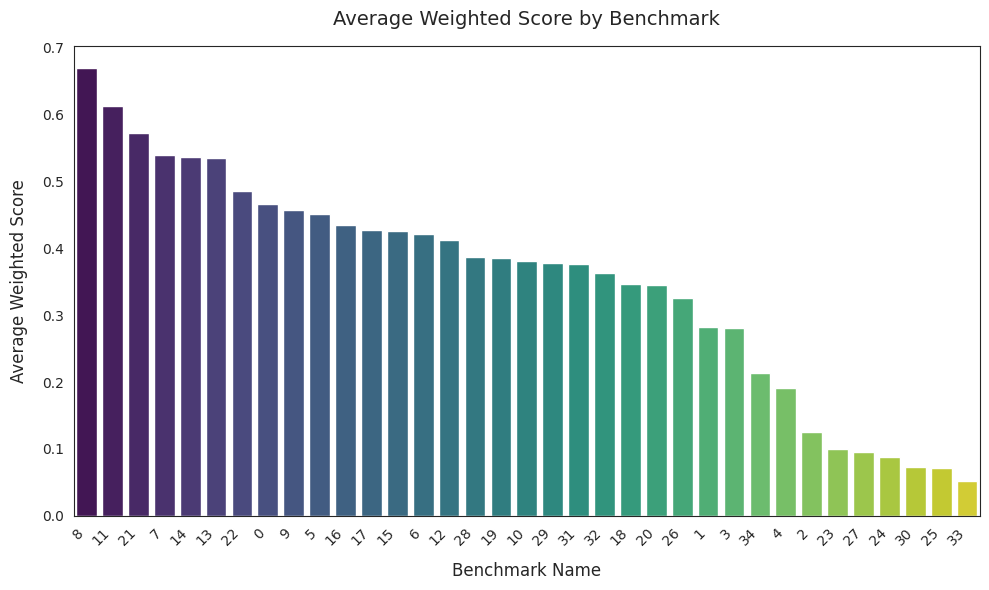

In [19]:
# 1. Figure out the order of benchmarks from highest average score to lowest
benchmark_order = df_unique.groupby('image_id')['weighted_score'].mean().sort_values(ascending=False).index

# 2. Set up the figure
plt.figure(figsize=(10, 6))

# 3. Create the bar chart
# errorbar=None removes the error lines on top of the bars to keep it clean
sns.barplot(
    data=df_unique, 
    x='image_id', 
    y='weighted_score', 
    order=benchmark_order, 
    errorbar=None, 
    palette='viridis'
)

# 4. Add labels and title
plt.title("Average Weighted Score by Benchmark", fontsize=14, pad=15)
plt.xlabel("Benchmark Name", fontsize=12, labelpad=10)
plt.ylabel("Average Weighted Score", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Average weighted score by Benchmark

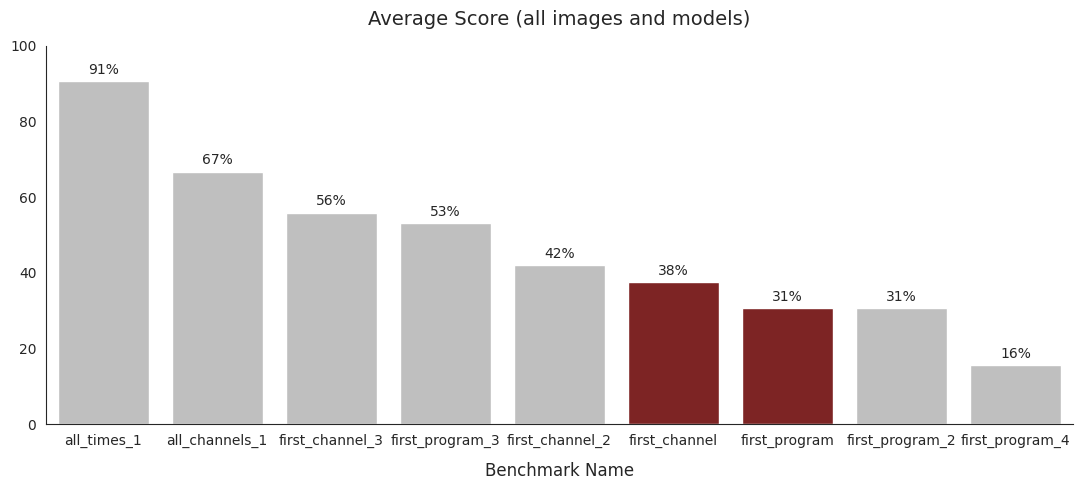

In [66]:
# 1. Figure out the order of benchmarks from highest average score to lowest
benchmark_order = df_unique.groupby('benchmark_name')['weighted_score'].mean().sort_values(ascending=False).index

# 2. Build a color list: grey by default, red for the 6th and 7th bars (indices 5 and 6)
RED = '#8c1515'
GREY = '#BFBFBF'

highlight = {'first_channel', 'first_program'}  # replace with the actual names you want red
palette = {name: (RED if name in highlight else GREY) for name in benchmark_order}

# 3. Set up the figure
plt.figure(figsize=(11, 5))

# 4. Create the bar chart — multiply by 100 to convert decimals to percentages
ax = sns.barplot(
    data=df_unique,
    x='benchmark_name',
    y=df_unique['weighted_score'] * 100,
    order=benchmark_order,
    errorbar=None,
    palette=palette,
    hue='benchmark_name',
    legend=False
)

# 5. Fix the y-axis between 0 and 100
ax.set_ylim(0, 100)

# 6. Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding= 3, fontsize=10)

# 7. Add labels and title
plt.title("Average Score (all images and models)", fontsize=14, pad=15)
plt.xlabel("Benchmark Name", fontsize=12, labelpad=10)
plt.ylabel("")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

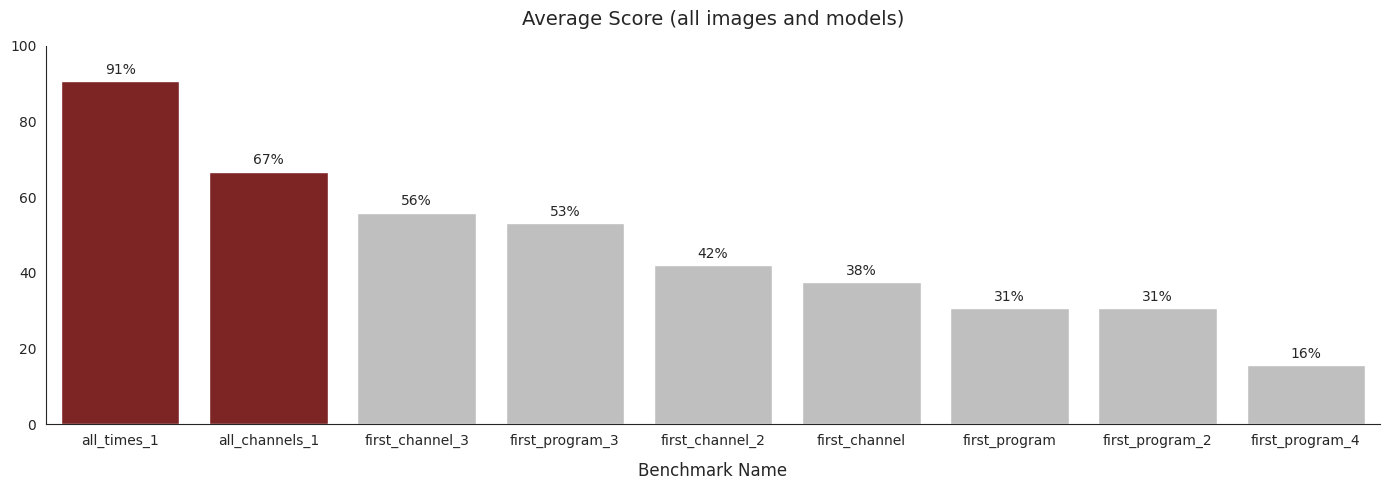

In [57]:
# 1. Figure out the order of benchmarks from highest average score to lowest
benchmark_order = df_unique.groupby('benchmark_name')['weighted_score'].mean().sort_values(ascending=False).index

# 2. Build a color list: grey by default, red for the 6th and 7th bars (indices 5 and 6)
RED = '#8c1515'
GREY = '#BFBFBF'

highlight = {'all_times_1', 'all_channels_1'}  # replace with the actual names you want red
palette = {name: (RED if name in highlight else GREY) for name in benchmark_order}

# 3. Set up the figure
plt.figure(figsize=(14, 5))

# 4. Create the bar chart — multiply by 100 to convert decimals to percentages
ax = sns.barplot(
    data=df_unique,
    x='benchmark_name',
    y=df_unique['weighted_score'] * 100,
    order=benchmark_order,
    errorbar=None,
    palette=palette,
    hue='benchmark_name',
    legend=False
)

# 5. Fix the y-axis between 0 and 100
ax.set_ylim(0, 100)

# 6. Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding= 3, fontsize=10)

# 7. Add labels and title
plt.title("Average Score (all images and models)", fontsize=14, pad=15)
plt.xlabel("Benchmark Name", fontsize=12, labelpad=10)
plt.ylabel("")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

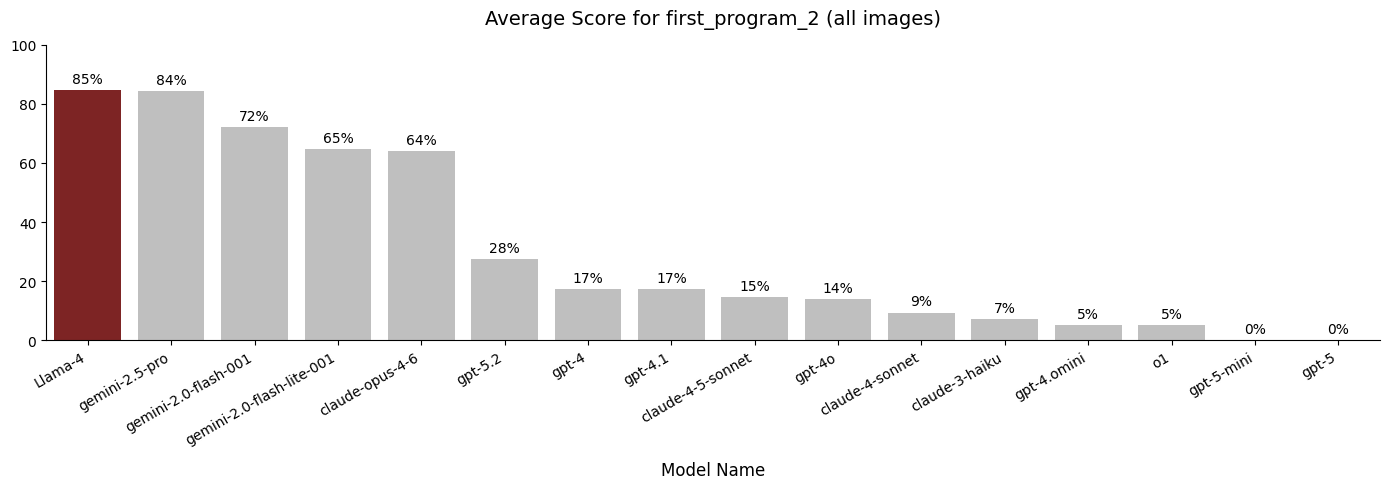

In [10]:
benchmark = 'first_program_2'

# 1. Filter to just this benchmark
df_bench = df_unique[df_unique['benchmark_name'] == benchmark]

# 2. Order models by average score, highest to lowest
model_order = df_bench.groupby('model_name')['weighted_score'].mean().sort_values(ascending=False).index

# 3. Build a color dict: grey by default, red for the highest and lowest scoring models
RED = '#8c1515'
GREY = '#BFBFBF'
highlight = {model_order[0]}
palette = {name: (RED if name in highlight else GREY) for name in model_order}

# 4. Set up the figure
plt.figure(figsize=(14, 5))

# 5. Create the bar chart
ax = sns.barplot(
    data=df_bench,
    x='model_name',
    y=df_bench['weighted_score'] * 100,
    order=model_order,
    errorbar=None,
    palette=palette,
    hue='model_name',
    legend=False,
)

# 6. Fix the y-axis between 0 and 100
ax.set_ylim(0, 100)

# 7. Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=3, fontsize=10)

# 8. Labels and title
plt.title(f"Average Score for {benchmark} (all images)", fontsize=14, pad=15)
plt.xlabel("Model Name", fontsize=12, labelpad=10)
plt.ylabel("")
sns.despine(ax=ax)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

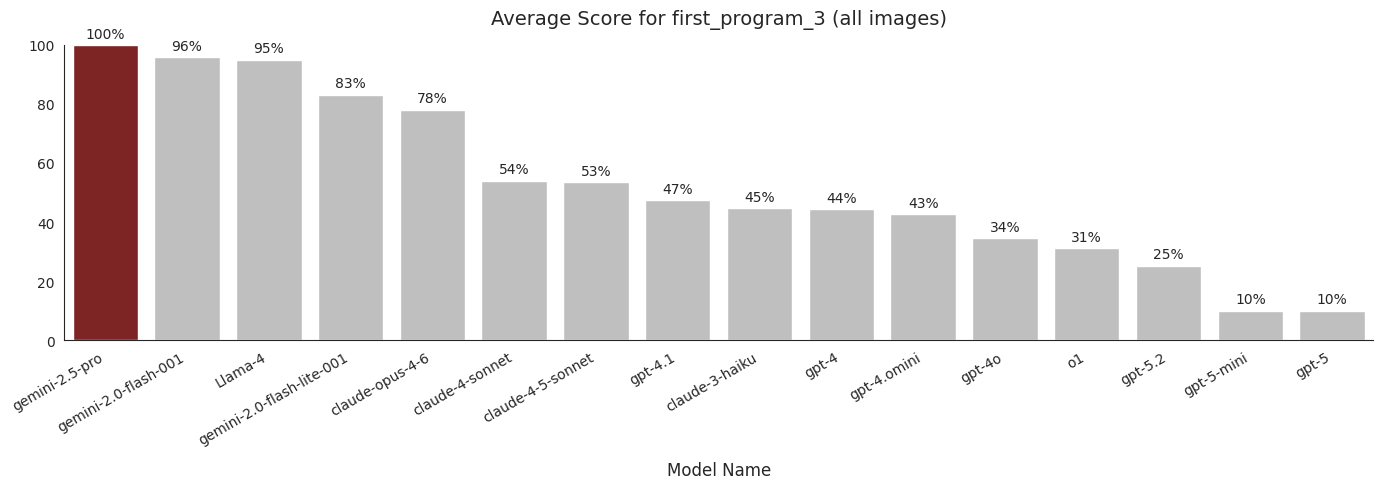

In [54]:
benchmark = 'first_program_3'

# 1. Filter to just this benchmark
df_bench = df_unique[df_unique['benchmark_name'] == benchmark]

# 2. Order models by average score, highest to lowest
model_order = df_bench.groupby('model_name')['weighted_score'].mean().sort_values(ascending=False).index

# 3. Build a color dict: grey by default, red for the highest and lowest scoring models
RED = '#8c1515'
GREY = '#BFBFBF'
highlight = {model_order[0]}
palette = {name: (RED if name in highlight else GREY) for name in model_order}

# 4. Set up the figure
plt.figure(figsize=(14, 5))

# 5. Create the bar chart
ax = sns.barplot(
    data=df_bench,
    x='model_name',
    y=df_bench['weighted_score'] * 100,
    order=model_order,
    errorbar=None,
    palette=palette,
    hue='model_name',
    legend=False,
)

# 6. Fix the y-axis between 0 and 100
ax.set_ylim(0, 100)

# 7. Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=3, fontsize=10)

# 8. Labels and title
plt.title(f"Average Score for {benchmark} (all images)", fontsize=14, pad=15)
plt.xlabel("Model Name", fontsize=12, labelpad=10)
plt.ylabel("")
sns.despine(ax=ax)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

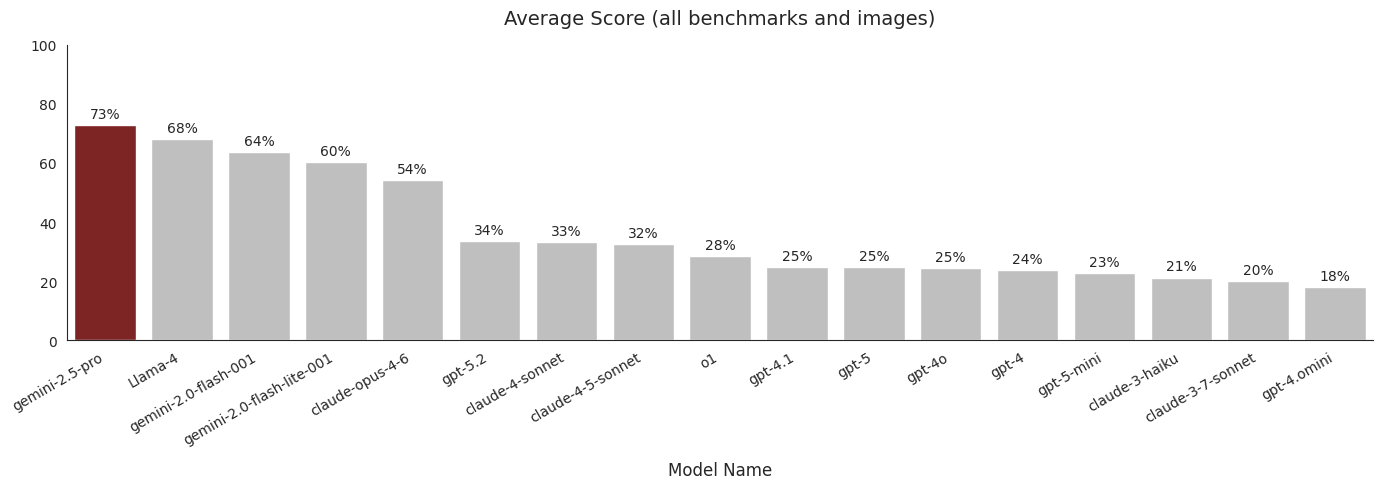

In [56]:
# 2. Order models by average score, highest to lowest
model_order = df_unique.groupby('model_name')['weighted_score'].mean().sort_values(ascending=False).index

# 3. Build a color dict: grey by default, red for the highest and lowest scoring models
RED = '#8c1515'
GREY = '#BFBFBF'
highlight = {model_order[0]}
palette = {name: (RED if name in highlight else GREY) for name in model_order}

# 4. Set up the figure
plt.figure(figsize=(14, 5))

# 5. Create the bar chart
ax = sns.barplot(
    data=df_unique,
    x='model_name',
    y=df_unique['weighted_score'] * 100,
    order=model_order,
    errorbar=None,
    palette=palette,
    hue='model_name',
    legend=False,
)

# 6. Fix the y-axis between 0 and 100
ax.set_ylim(0, 100)

# 7. Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=3, fontsize=10)

# 8. Labels and title
plt.title(f"Average Score (all benchmarks and images)", fontsize=14, pad=15)
plt.xlabel("Model Name", fontsize=12, labelpad=10)
plt.ylabel("")
sns.despine(ax=ax)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Heatmap by Benchmark & Model

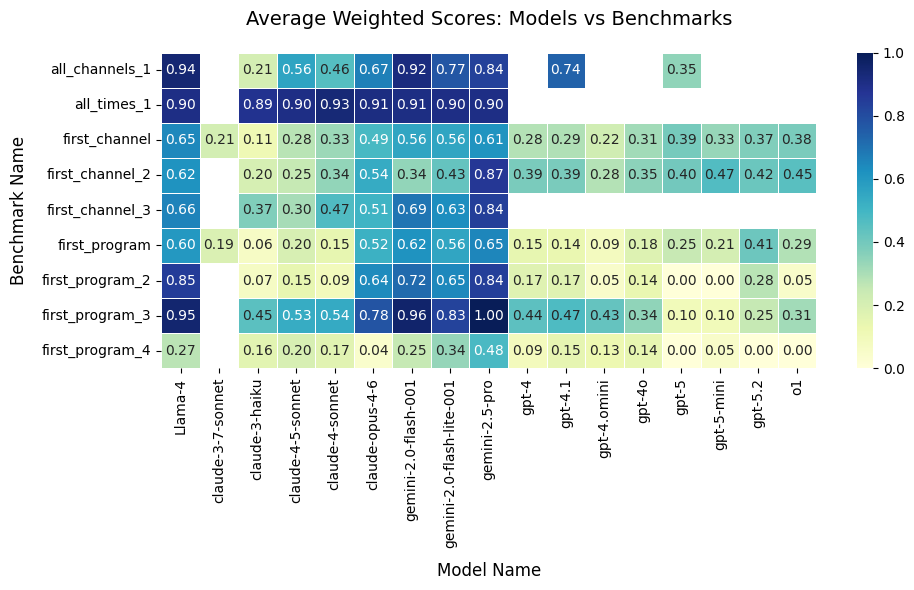

In [70]:
# 1. Assuming you already have 'overall_scores' from the previous step:
overall_scores = df_unique.groupby(['benchmark_name', 'model_name'])['weighted_score'].mean().reset_index()

# 2. Create the pivot table
pivot_summary = overall_scores.pivot(index='benchmark_name', columns='model_name', values='weighted_score')

# 3. Set up the matplotlib figure size
plt.figure(figsize=(10, 6))

# 4. Create the heatmap
# annot=True puts the actual numbers on the map
# cmap="YlGnBu" gives it a nice Yellow-Green-Blue color scale (you can also use "viridis" or "coolwarm")
# fmt=".2f" formats the numbers to 2 decimal places
sns.heatmap(pivot_summary, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=.5)

# 5. Add labels and a title to make it presentation-ready
plt.title("Average Weighted Scores: Models vs Benchmarks", pad=20, fontsize=14)
plt.xlabel("Model Name", labelpad=10, fontsize=12)
plt.ylabel("Benchmark Name", labelpad=10, fontsize=12)

# Ensure the layout fits well and display it
plt.tight_layout()
plt.show()

# Spot Checking Results

In [50]:
filtered_df = df_long[(df_long['model_name'] == 'gemini-2.5-pro') & (df_long['benchmark_name'] == 'first_program_3')]
pd.set_option('display.max_rows', None)
filtered_df


,task_id,model_name,model_id,benchmark_id,benchmark_name,image_id,weighted_score,field,composite_score,weighted_composite_score,metric,value,predicted,expected
6813,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,null_accuracy,1.0,News,News
6814,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,null_tp,1.0,News,News
6815,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,null_tn,0.0,News,News
6816,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,null_fp,0.0,News,News
6817,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,null_fn,0.0,News,News
6818,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,null_precision,1.0,News,News
6819,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,null_recall,1.0,News,News
6820,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,levenshtein_similarity,1.0,News,News
6821,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,levenshtein_distance,0.0,News,News
6822,4366,gemini-2.5-pro,13,9,first_program_3,22,1.0,first_program_name,1.0,1.0,char_f1,1.0,News,News


In [47]:
filtered_df = df_unique[(df_unique['model_name'] == 'gemini-2.5-pro') & (df_unique['benchmark_name'] == 'first_channel_2')]
filtered_df

,task_id,model_name,model_id,benchmark_id,benchmark_name,image_id,weighted_score,field,composite_score,weighted_composite_score,metric,value,predicted,expected
4398,3882,gemini-2.5-pro,13,6,first_channel_2,7,1.0000,first_channel_2,1.0000,1.0000,word_iou,1.0000,2,2
4401,3884,gemini-2.5-pro,13,6,first_channel_2,14,1.0000,first_channel_2,1.0000,1.0000,word_iou,1.0000,FOOD,FOOD
4402,3885,gemini-2.5-pro,13,6,first_channel_2,19,0.6667,first_channel_2,0.6667,0.6667,word_iou,0.6667,2 KATU 9292145,2 KATU
4403,3886,gemini-2.5-pro,13,6,first_channel_2,22,1.0000,first_channel_2,1.0000,1.0000,word_iou,1.0000,KCBS 2,KCBS 2 2 2 2 2
4404,3887,gemini-2.5-pro,13,6,first_channel_2,26,0.5000,first_channel_2,0.5000,0.5000,word_iou,0.5000,2 003 2,2 3 003 2 KHON
4405,3880,gemini-2.5-pro,13,6,first_channel_2,0,1.0000,first_channel_2,1.0000,1.0000,word_iou,1.0000,3,3
4406,3881,gemini-2.5-pro,13,6,first_channel_2,3,0.5000,first_channel_2,0.5000,0.5000,word_iou,0.5000,FOX/7.1,Fox/7.1 2 2 2
4407,3883,gemini-2.5-pro,13,6,first_channel_2,11,1.0000,first_channel_2,1.0000,1.0000,word_iou,1.0000,2 WCBS,2 WCBS
4427,3888,gemini-2.5-pro,13,6,first_channel_2,28,1.0000,first_channel_2,1.0000,1.0000,word_iou,1.0000,4 WDAF,4 WDAF
4428,3889,gemini-2.5-pro,13,6,first_channel_2,31,1.0000,first_channel_2,1.0000,1.0000,word_iou,1.0000,KOMO 4 4 ABC,KOMO ABC 4 4


# Benchmark Score by Metric & Model 

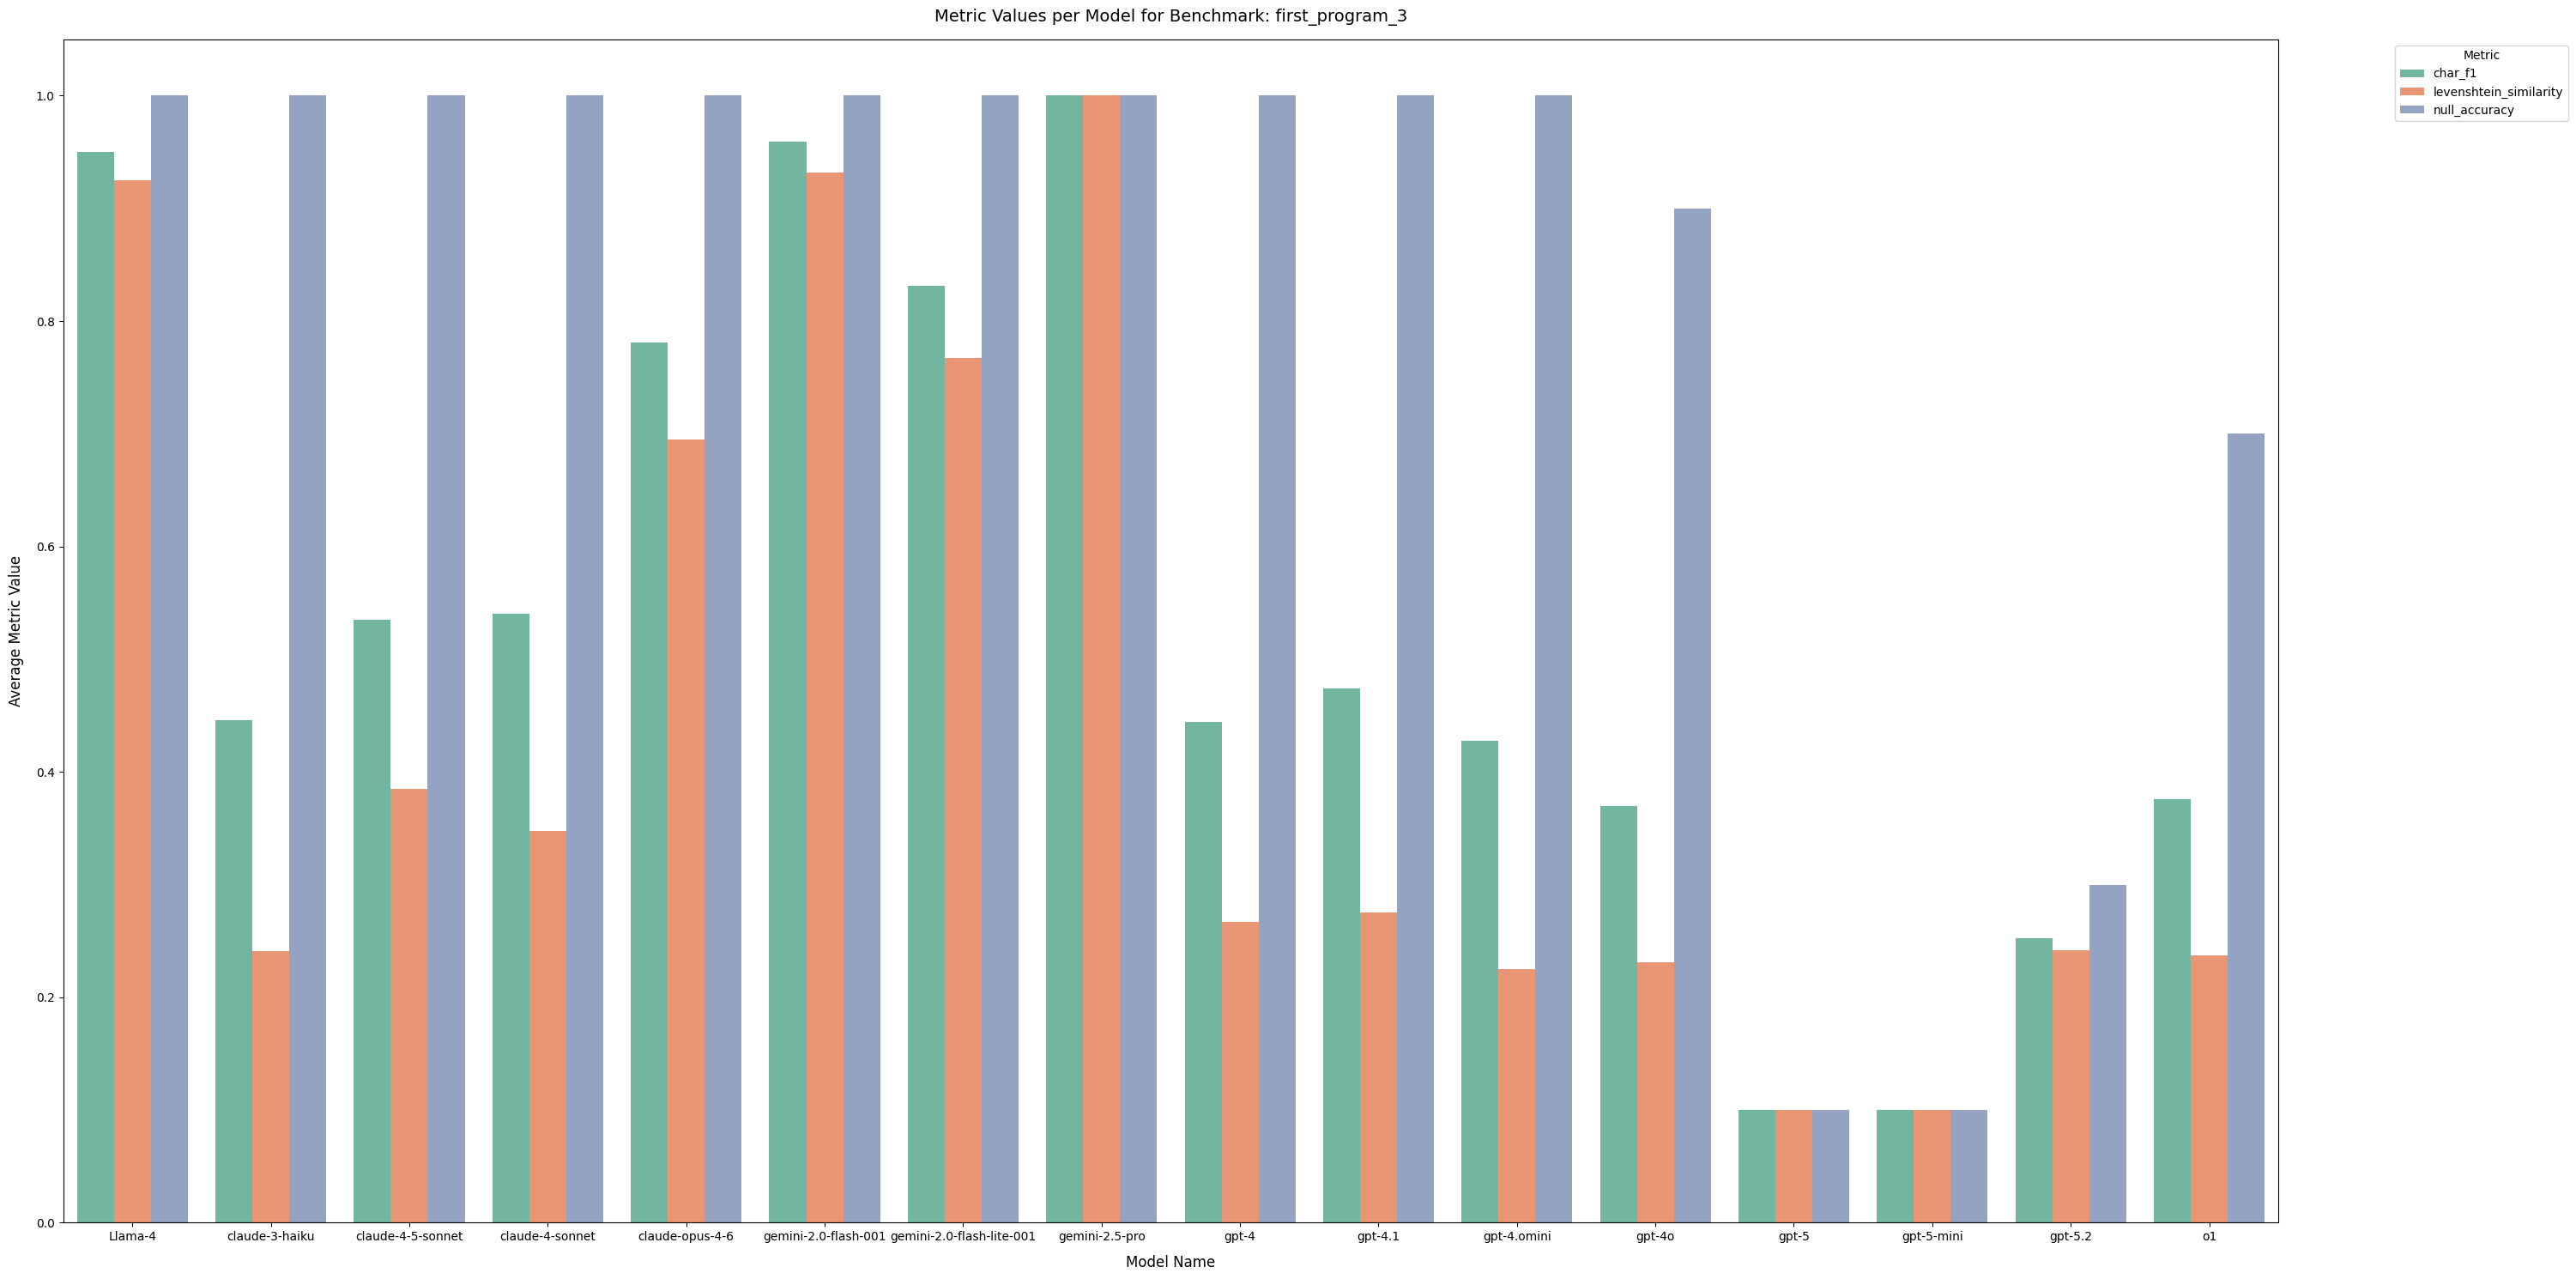

In [48]:
# 1. Define the specific benchmark and the metrics you want to keep
# Replace 'your_benchmark_name_here' with the actual benchmark name from your data
target_benchmark = 'first_program_3' 
target_metrics = ['char_f1', 'levenshtein_similarity', 'null_accuracy']

# 2. Filter the dataframe
# Keep only the target benchmark
df_filtered = df_long[df_long['benchmark_name'] == target_benchmark]

# Keep only the rows where the 'metric' column matches one of our target metrics
df_filtered = df_filtered[df_filtered['metric'].isin(target_metrics)]

# 3. Ensure 'value' is numeric (sometimes data imports format these as strings)
df_filtered['value'] = pd.to_numeric(df_filtered['value'], errors='coerce')

# 4. Aggregate the actual metric VALUES (swapped out weighted_score)
metric_scores = df_filtered.groupby(['model_name', 'metric'])['value'].mean().reset_index()

# 5. Set up the visualization
plt.figure(figsize=(30,15))

# Create the grouped bar chart
sns.barplot(
    data=metric_scores,
    x='model_name',          # Models are the main categories on the x-axis
    y='value',               # The ACTUAL metric values are now on the y-axis
    hue='metric',            # The 3 metrics are grouped side-by-side for each model
    palette='Set2'
)

# 6. Make the chart presentable
plt.title(f"Metric Values per Model for Benchmark: {target_benchmark}", fontsize=14, pad=15)
plt.xlabel("Model Name", fontsize=12, labelpad=10)
plt.ylabel("Average Metric Value", fontsize=12, labelpad=10)

# Move the legend outside the chart so it doesn't block the bars
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout and display
plt.tight_layout()
plt.show()

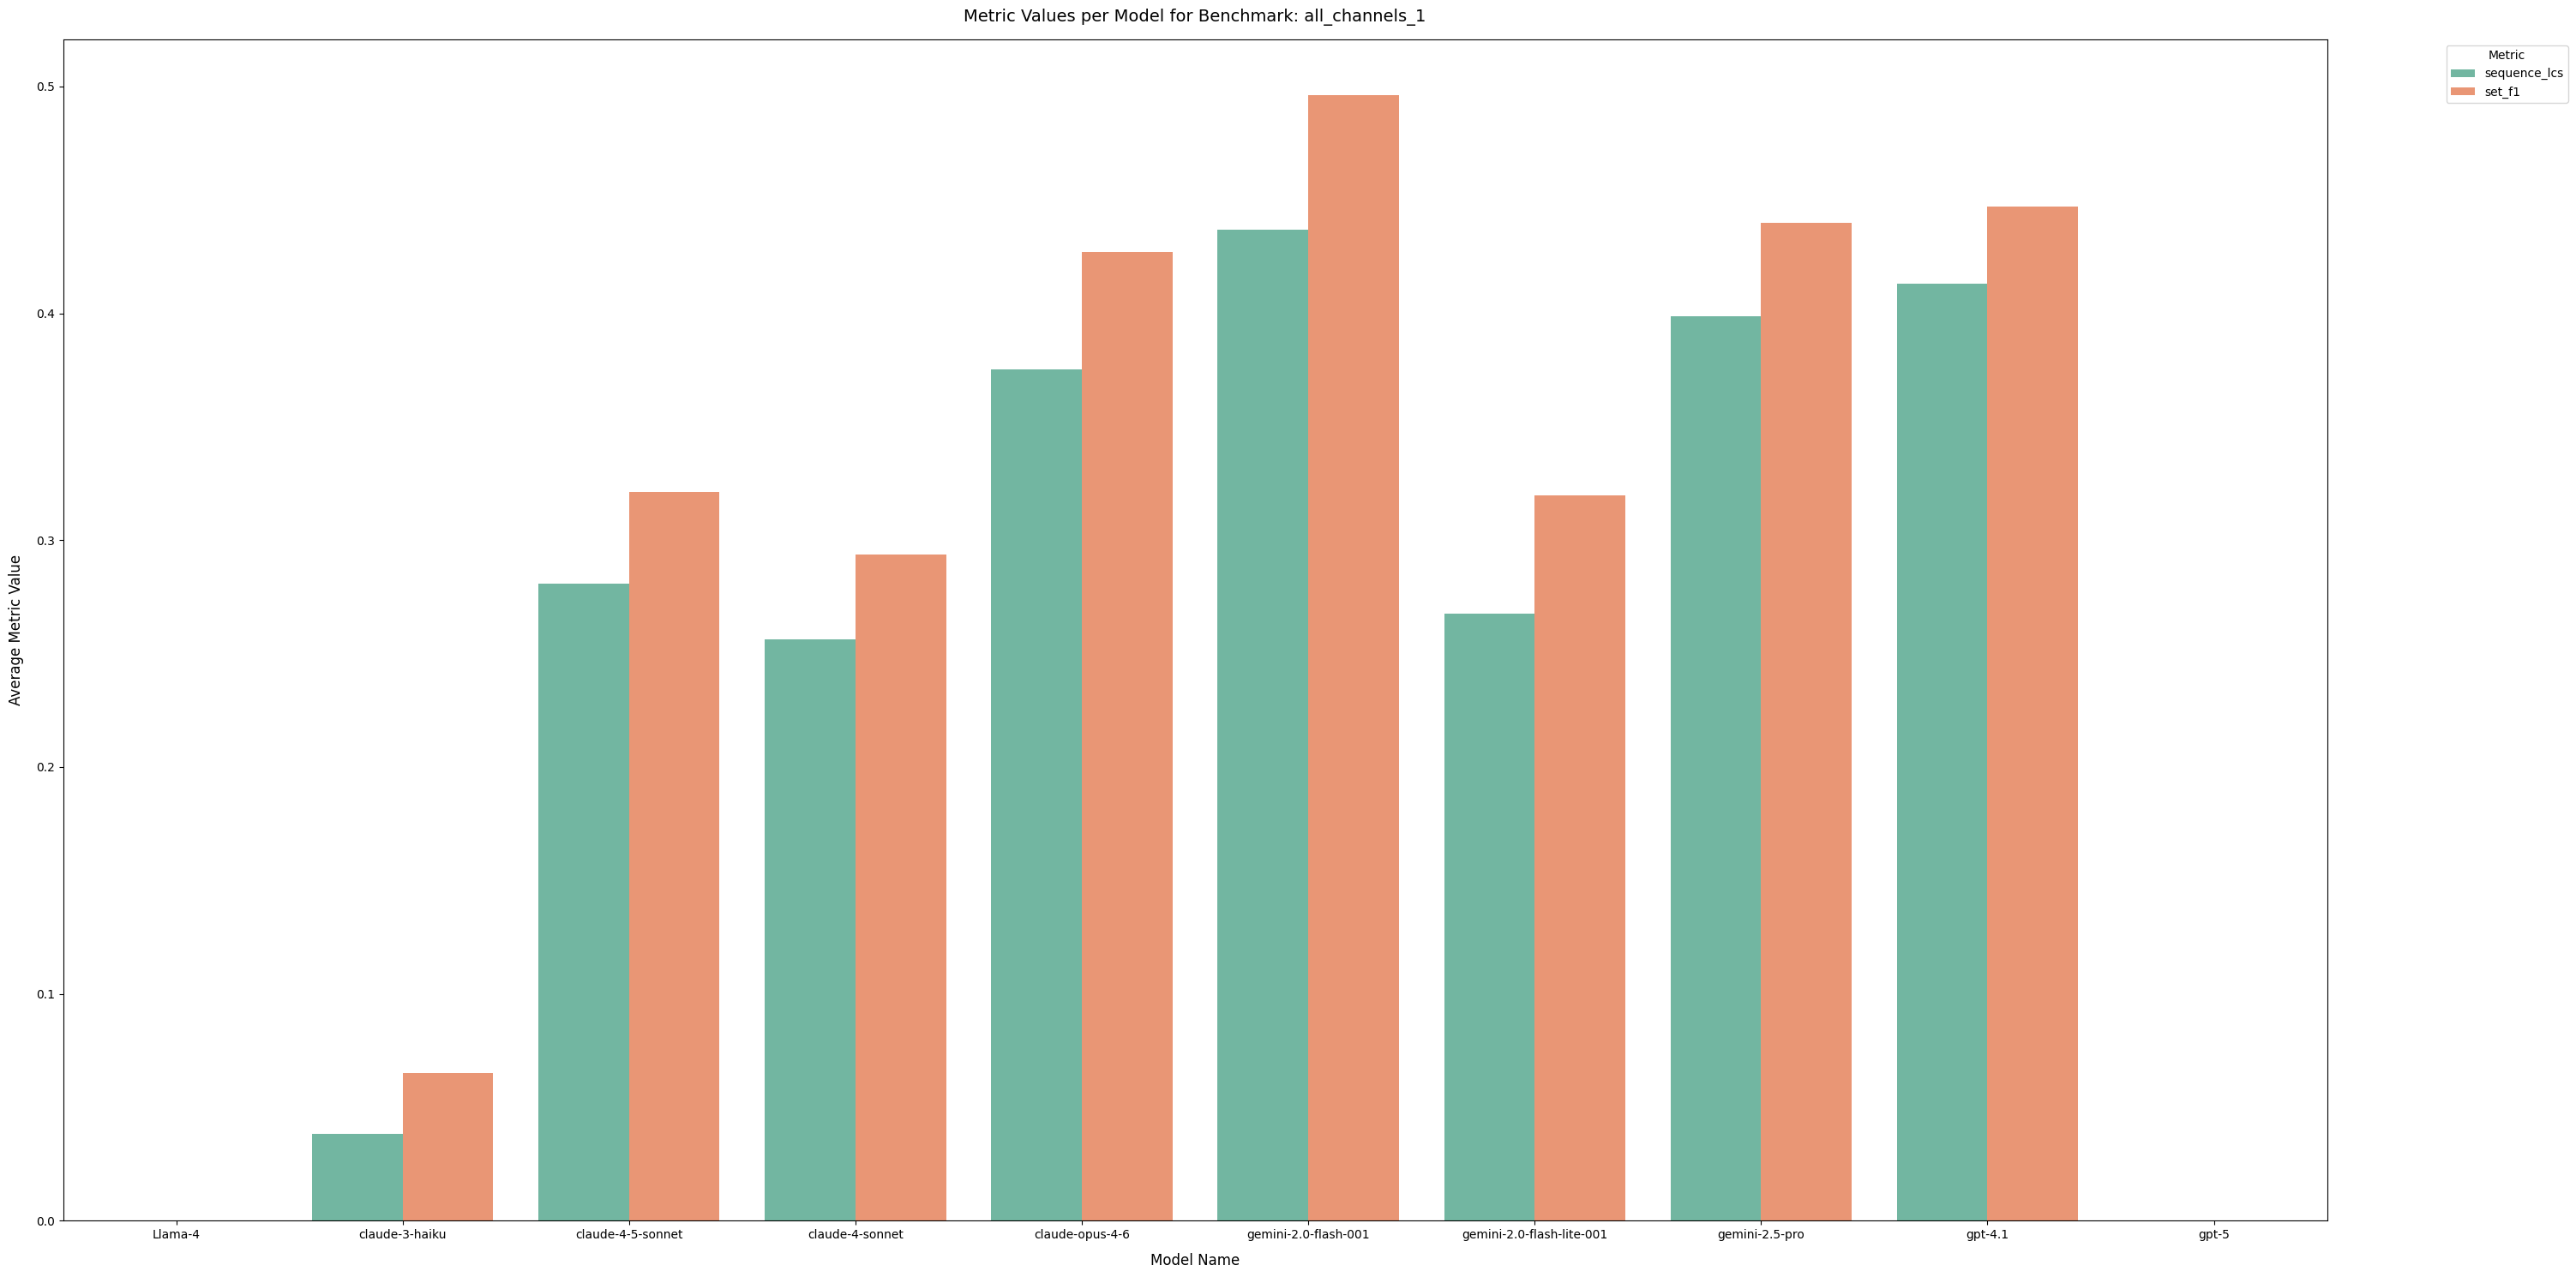

In [51]:
# 1. Define the specific benchmark and the metrics you want to keep
# Replace 'your_benchmark_name_here' with the actual benchmark name from your data
target_benchmark = 'all_channels_1' 
target_metrics = ['set_f1', 'sequence_lcs']

# 2. Filter the dataframe
# Keep only the target benchmark
df_filtered = df_long[df_long['benchmark_name'] == target_benchmark]

# Keep only the rows where the 'metric' column matches one of our target metrics
df_filtered = df_filtered[df_filtered['metric'].isin(target_metrics)]

# 3. Ensure 'value' is numeric (sometimes data imports format these as strings)
df_filtered['value'] = pd.to_numeric(df_filtered['value'], errors='coerce')

# 4. Aggregate the actual metric VALUES (swapped out weighted_score)
metric_scores = df_filtered.groupby(['model_name', 'metric'])['value'].mean().reset_index()

# 5. Set up the visualization
plt.figure(figsize=(30,15))

# Create the grouped bar chart
sns.barplot(
    data=metric_scores,
    x='model_name',          # Models are the main categories on the x-axis
    y='value',               # The ACTUAL metric values are now on the y-axis
    hue='metric',            # The 3 metrics are grouped side-by-side for each model
    palette='Set2'
)

# 6. Make the chart presentable
plt.title(f"Metric Values per Model for Benchmark: {target_benchmark}", fontsize=14, pad=15)
plt.xlabel("Model Name", fontsize=12, labelpad=10)
plt.ylabel("Average Metric Value", fontsize=12, labelpad=10)

# Move the legend outside the chart so it doesn't block the bars
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout and display
plt.tight_layout()
plt.show()

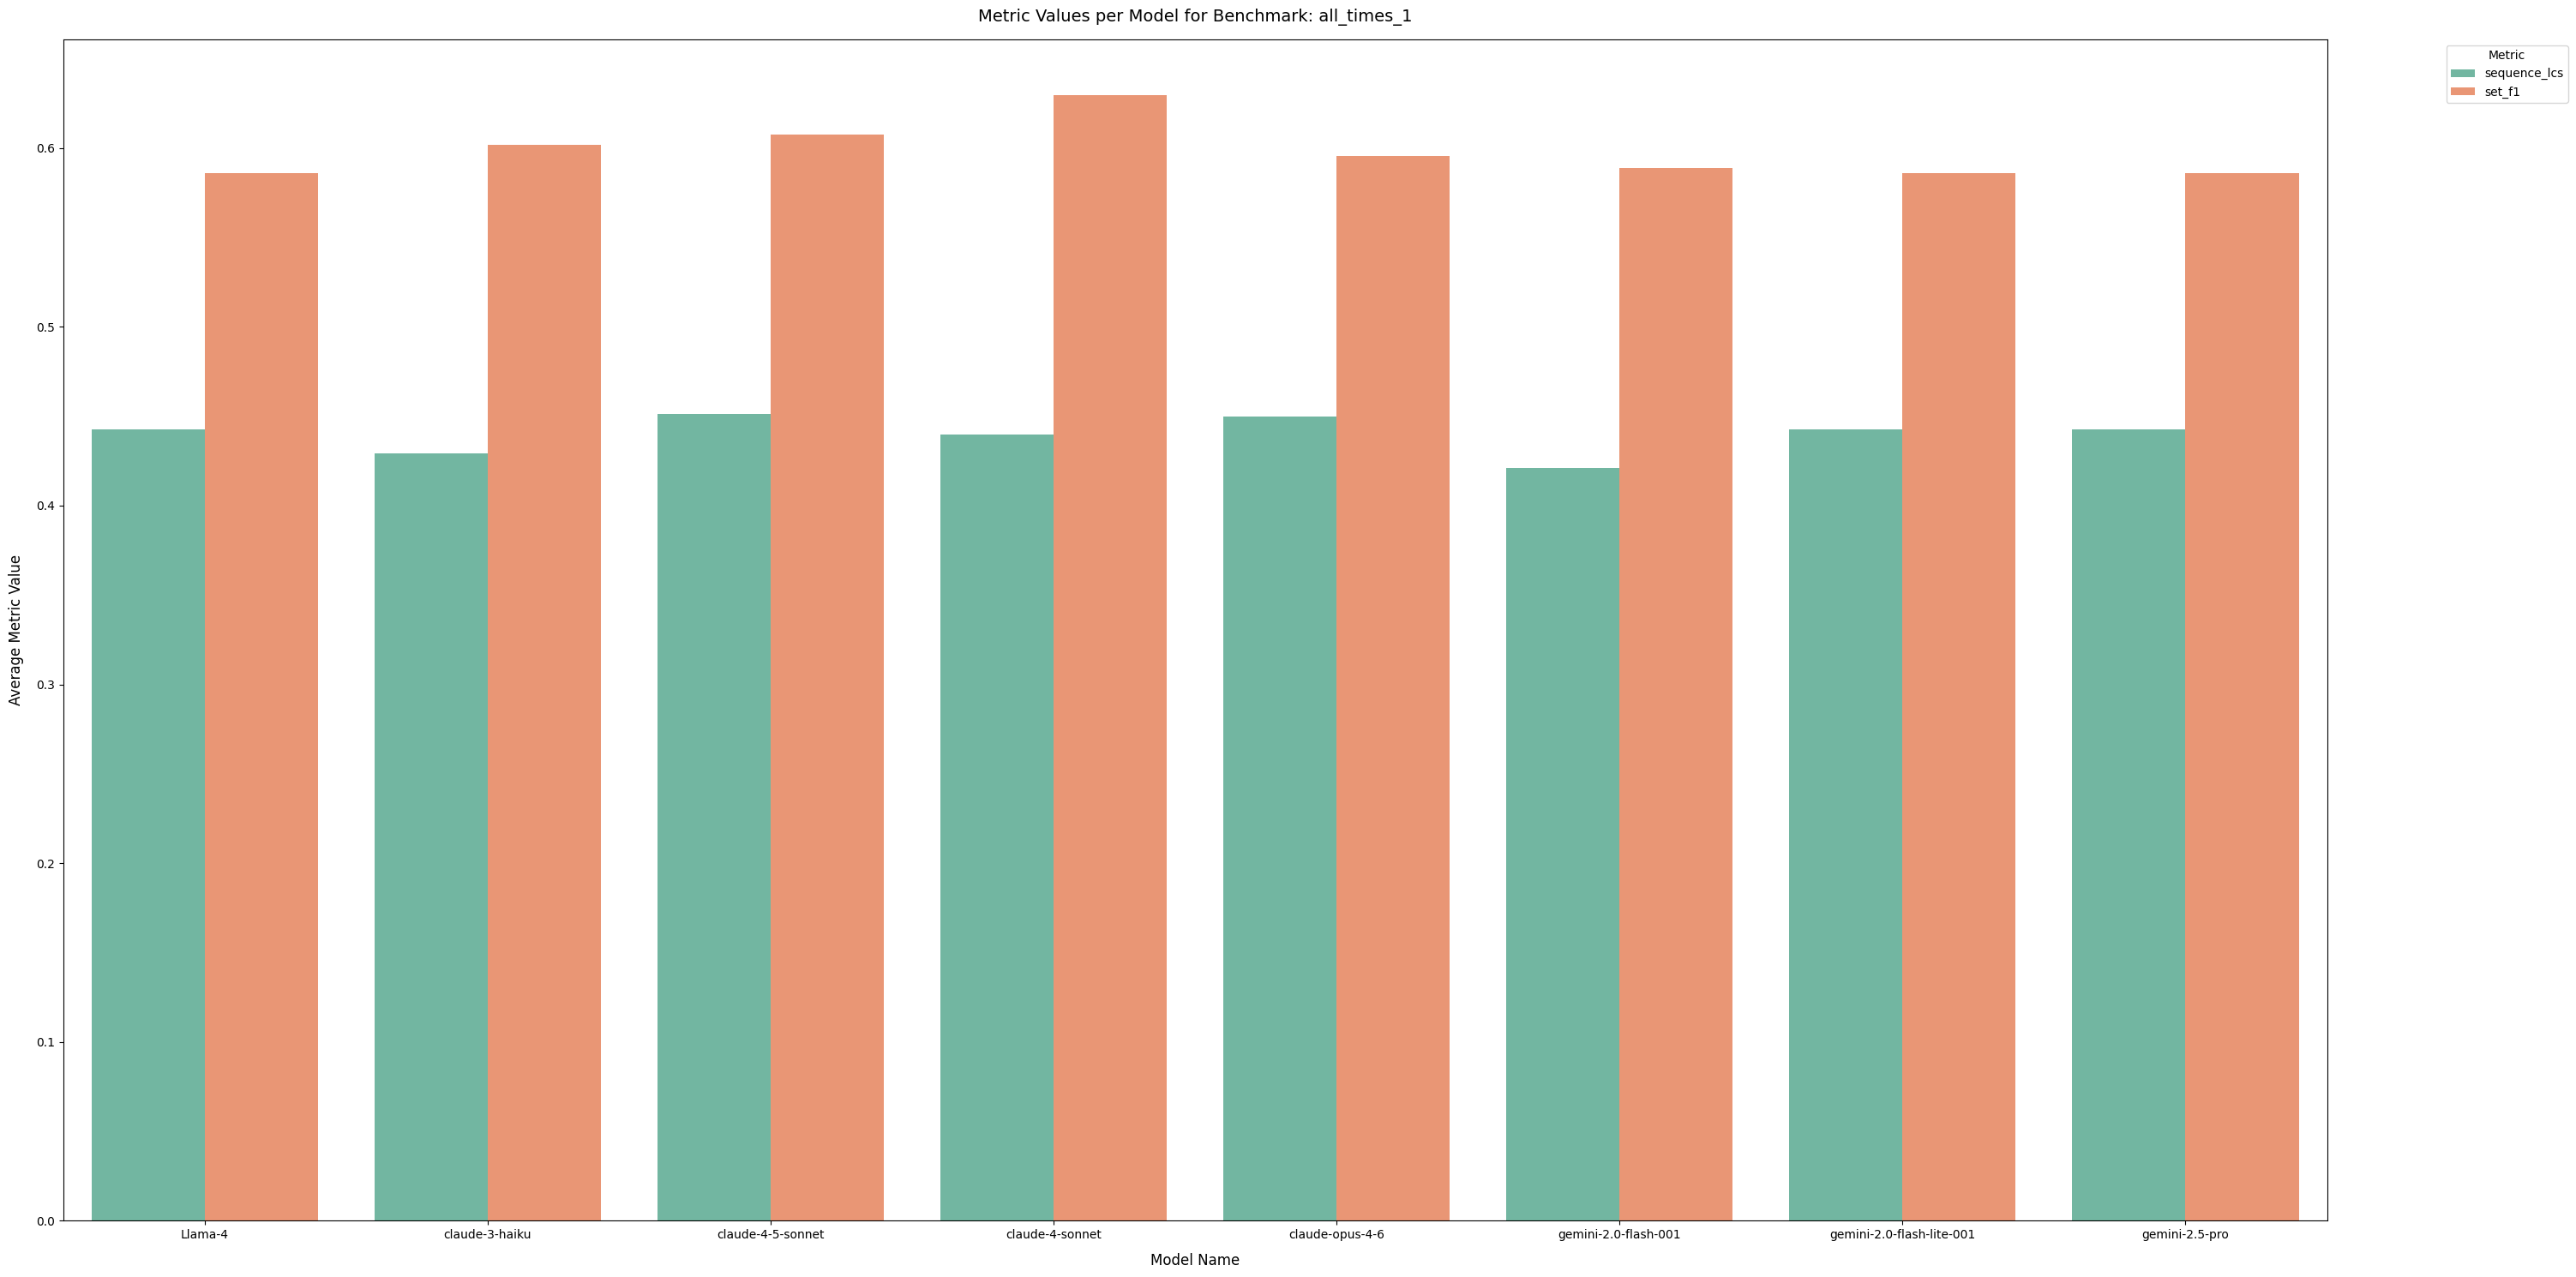

In [52]:
# 1. Define the specific benchmark and the metrics you want to keep
# Replace 'your_benchmark_name_here' with the actual benchmark name from your data
target_benchmark = 'all_times_1' 
target_metrics = ['set_f1', 'sequence_lcs']

# 2. Filter the dataframe
# Keep only the target benchmark
df_filtered = df_long[df_long['benchmark_name'] == target_benchmark]

# Keep only the rows where the 'metric' column matches one of our target metrics
df_filtered = df_filtered[df_filtered['metric'].isin(target_metrics)]

# 3. Ensure 'value' is numeric (sometimes data imports format these as strings)
df_filtered['value'] = pd.to_numeric(df_filtered['value'], errors='coerce')

# 4. Aggregate the actual metric VALUES (swapped out weighted_score)
metric_scores = df_filtered.groupby(['model_name', 'metric'])['value'].mean().reset_index()

# 5. Set up the visualization
plt.figure(figsize=(30,15))

# Create the grouped bar chart
sns.barplot(
    data=metric_scores,
    x='model_name',          # Models are the main categories on the x-axis
    y='value',               # The ACTUAL metric values are now on the y-axis
    hue='metric',            # The 3 metrics are grouped side-by-side for each model
    palette='Set2'
)

# 6. Make the chart presentable
plt.title(f"Metric Values per Model for Benchmark: {target_benchmark}", fontsize=14, pad=15)
plt.xlabel("Model Name", fontsize=12, labelpad=10)
plt.ylabel("Average Metric Value", fontsize=12, labelpad=10)

# Move the legend outside the chart so it doesn't block the bars
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout and display
plt.tight_layout()
plt.show()